In [1]:
import pandas as pd
from src.processing import find_pareto_front
from src.visualization import display_pareto_front, display_two_pareto_fronts, display_fitness_landscape_with_2pareto
from src.metrics import calculate_gamma_convergence_metric, print_gamma_metric

In [2]:
df = pd.read_parquet('data/df_surrogate.parquet')
df_pareto_real = pd.read_parquet('data/pareto_df3.parquet')

print(df.shape)
#print(df.columns)
df.head()

(1000000, 46)


,registro,fitness1_eq0,fitness1_eq1,fitness1_eq2,fitness1_eq3,fitness1_eq4,fitness1_eq5,fitness1_eq6,fitness1_eq7,fitness1_eq8,...,erro_abs1_c3,fitness2_c1,fitness2_c2,fitness2_c3,erro2_c1,erro_abs2_c1,erro2_c2,erro_abs2_c2,erro2_c3,erro_abs2_c3
0,0,0.000000,1.0,0.00000,0.000000,0.00000,0.000000,0.0000,2.67401,0.162091,...,0.044322,3.177411,3.089214,3.283747,0.199269,0.199269,0.287465,0.287465,0.092933,0.092933
1,1,0.000007,1.0,0.00004,0.000025,0.00005,0.000075,0.0001,2.67401,0.161838,...,0.044387,3.177411,3.089214,3.283747,0.199369,0.199369,0.287566,0.287566,0.093034,0.093034
2,2,0.000015,1.0,0.00008,0.000050,0.00010,0.000150,0.0002,2.67401,0.161585,...,0.044452,3.177411,3.089214,3.283747,0.199470,0.199470,0.287667,0.287667,0.093134,0.093134
3,3,0.000022,1.0,0.00012,0.000075,0.00015,0.000225,0.0003,2.67401,0.161333,...,0.044517,3.177411,3.089214,3.283747,0.199570,0.199570,0.287767,0.287767,0.093235,0.093235
4,4,0.000030,1.0,0.00016,0.000100,0.00020,0.000300,0.0004,2.67401,0.161080,...,0.044581,3.177411,3.089214,3.283747,0.199671,0.199671,0.287868,0.287868,0.093335,0.093335


# 1. Força bruta

In [3]:
df_predicted = df.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)
df_pareto_surrogate = find_pareto_front(df_predicted)
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_surrogate)

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 318 pontos.
Isso representa 0.0318% do espaço de busca.


MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 10,344
   • Pontos no front encontrado: 318

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.898084
   • Desvio Padrão:            0.449989

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.336506
   • Máxima:                   3.432191
   • Mediana:                  0.831093

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


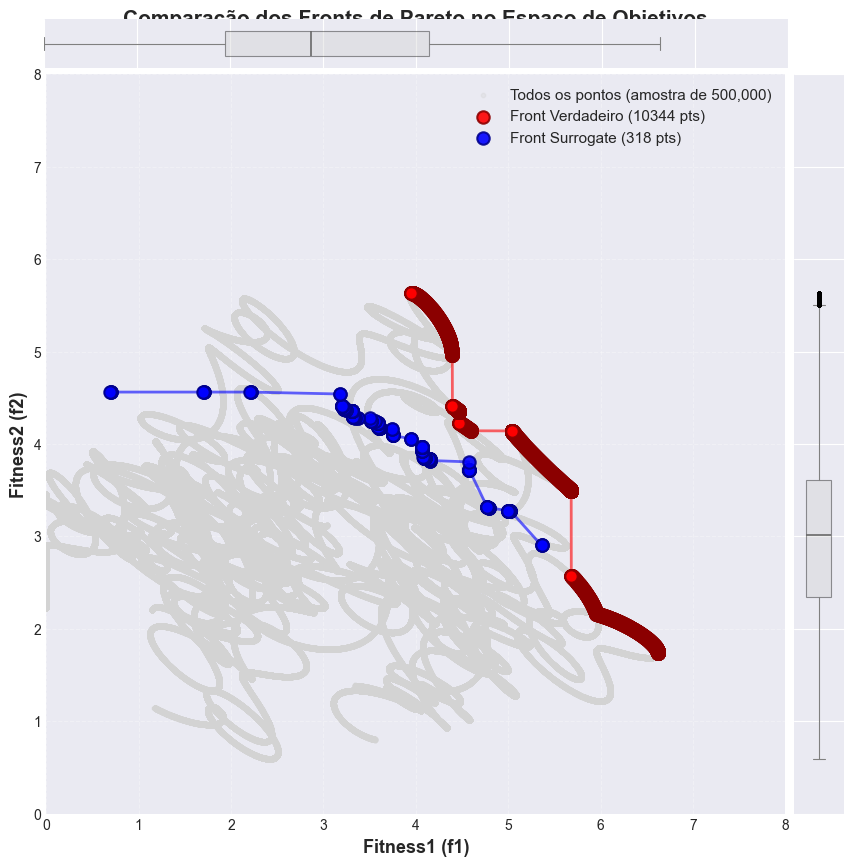

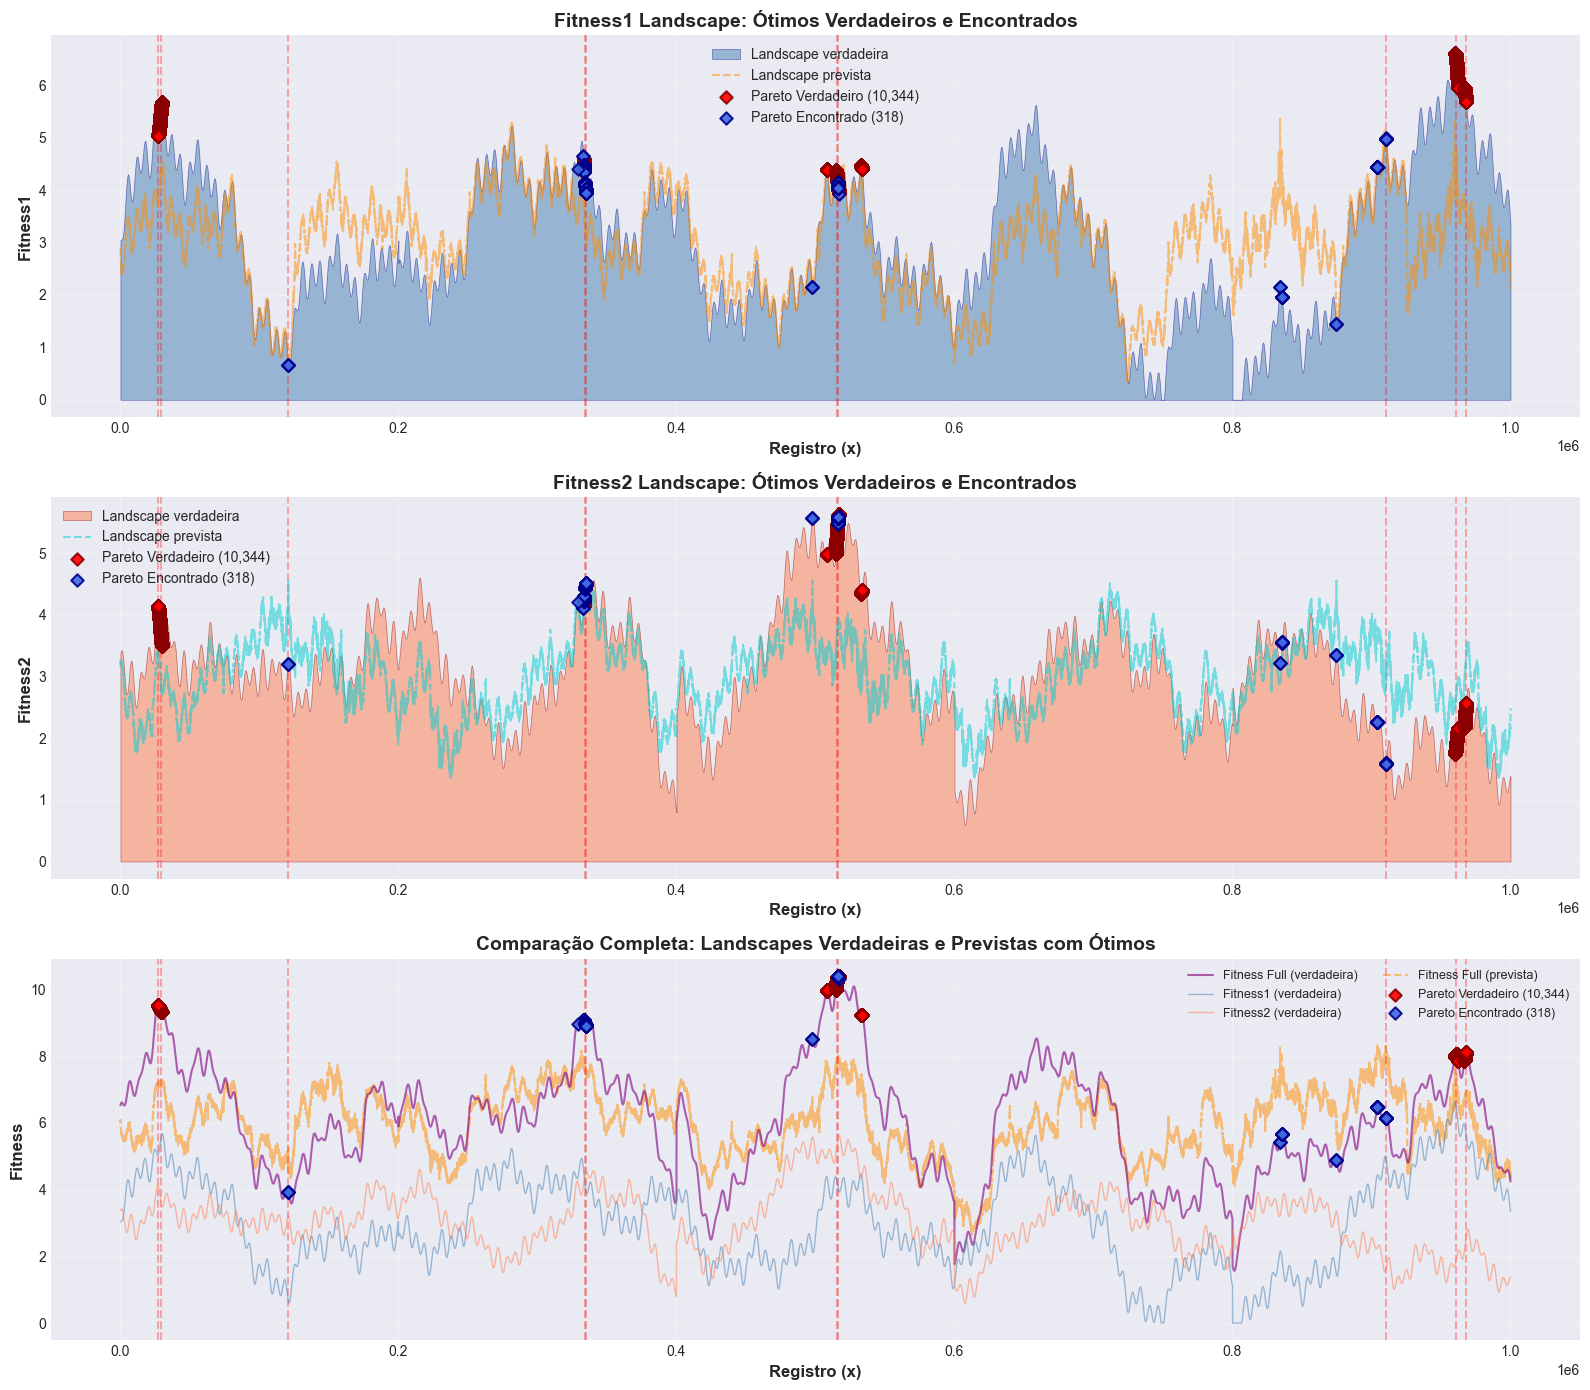

In [4]:
print_gamma_metric(gamma_results)
display_two_pareto_fronts(df, df_pareto_real, df_pareto_surrogate)
display_fitness_landscape_with_2pareto(df, df_pareto_real, df_pareto_surrogate)

# 2. NSGA-II

Vamos implementar o algoritmo NSGA-II de duas formas:
1. Usando a biblioteca pymoo (implementação otimizada)
2. Implementação própria seguindo o algoritmo original

Configuração dos Experimentos
* Cada indivíduo será representado como uma lista de 6 dígitos [d1, d2, d3, d4, d5, d6], onde cada elemento pode variar de 0 a 9
* Formando um número de 0 a 999999 que representa um registro do dataframe (df_landscape).

### 2.1. Pymoo

In [5]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
import copy


####################################################################################################
####################################################################################################

### Mapeamento genótipo <> fenótipo
def genotype_to_registro(genotype):
    """Converte lista de 6 dígitos em número de registro"""
    return int(''.join(map(str, genotype)))

def registro_to_genotype(registro):
    """Converte número de registro em lista de 6 dígitos"""
    return [int(d) for d in f"{registro:06d}"]


# Definição do problema para pymoo
class DigitOptimizationProblem(Problem):
    
    ##############################################
    ############### Inicializa problema / genótipo
    def __init__(self, df_landscape, config):
        """
        Problema de otimização bi-objetivo onde cada indivíduo é representado
        por 6 dígitos (0-9) que formam um registro do dataframe
        """
        ### definindo o problema
        self.df_landscape = df_landscape
        self.fitness_cols = config['fitness_cols']
        self.maximize = config['maximize']

        ### definindo o genótipo        
        super().__init__(
            n_var    = config['tamanho_genotipo'],      # 6 variáveis (dígitos)
            n_obj    = config['n_objetivos'],           # 2 objetivos
            n_constr = config['n_restricoes'],          # Sem restrições
            xl       = config['limite_inferior'],       # Limite inferior
            xu       = config['limite_superior'],       # Limite superior
            type_var = config['tipo_variavel_genotipo'] # Variáveis inteiras
        )
    
    ##############################################
    ########################### Fitness evaluation

    ### Avalia Fitness 1 indivíduo
    def individual_fitness_evaluation(self, genotype, df_landscape, fitness_cols, maximize = False):
        """Obtém fitness do dataframe para um determinado genótipo"""

        # Identifica a solucao no dataframe de fitness landscape
        registro = genotype_to_registro(genotype)
        row = df_landscape[df_landscape['registro'] == registro]

        # Coleta fitness (se registro não existe, retornar valores muito ruins)
        if len(row) == 0:
            fitness1 = 1e6
            fitness2 = 1e6
        else:
            fitness1 = row[fitness_cols[0]].values[0]
            fitness2 = row[fitness_cols[1]].values[0]

        # Se for um problema de maximizacao, inverte os valores de fitness
        if maximize:
            fitness1 = -fitness1
            fitness2 = -fitness2
        
        return [fitness1, fitness2]


    ### Avalia Fitness 1 população
    def _evaluate(self, X, out, *args, **kwargs):
        """
        Avalia a população X e retorna os objetivos
        """
        n_individuals = X.shape[0]
        objectives = np.zeros((n_individuals, 2))
        
        for i in range(n_individuals):
            genotype = X[i].tolist()
            objectives[i] = self.individual_fitness_evaluation(genotype, self.df_landscape, self.fitness_cols, self.maximize)
        
        out["F"] = objectives



####################################################################################################
####################################################################################################
def run_nsga2_pymoo(config, 
                    df_landscape,
                    return_initial_pop=False,
                    ):
    '''
    Funcao para executar o NSGA-II com a biblioteca pymoo
    '''

    ##############################################
    ############################# Execucao NSGA-II

    # Define o problema
    problem = DigitOptimizationProblem(df_landscape, config)

    # Configura o algoritmo
    algorithm = NSGA2(
        pop_size=config['population_size'],
        sampling=IntegerRandomSampling(),
        crossover=SBX(prob=config['crossover_prob'], eta=config['crossover_eta'], vtype=int),
        mutation=PM(prob=config['mutation_prob'], eta=config['mutation_eta'], vtype=int),
        eliminate_duplicates=True
    )

    # Executa otimização (pymoo sempre minimiza)
    resultado_otimizacao = minimize(
        problem,
        algorithm,
        ('n_gen', config['n_generations']),
        seed=config['seed'],
        save_history=return_initial_pop,  # Salvar histórico para capturar população inicial
        verbose = False #True
    )


    ##############################################
    ################################### Resultados

    # Extrai soluções do front de Pareto
    pareto_genotypes = resultado_otimizacao.X
    pareto_objectives = resultado_otimizacao.F

    # Converte para registros e cria dataframe
    registros = [genotype_to_registro(g) for g in pareto_genotypes]
    df_pareto = df_landscape[df_landscape['registro'].isin(registros)].copy()

    # Capturar população inicial
    if return_initial_pop:
        initial_population = resultado_otimizacao.history[0].pop.get("X")
    else:
        initial_population = None

    print(f"\n✅ Otimização concluída!")
    print(f"Soluções encontradas no front: {len(pareto_genotypes)}")
    print(f"Registros únicos no dataframe: {len(df_pareto)}")


    return df_pareto, resultado_otimizacao, initial_population

### 2.2. my NSGA-II
Implementação Própria do algoritmo NSGA-II seguindo o paper original de Deb et al. (2002)

In [6]:
from src.nsgaII import run_my_nsga2

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Experimentos

In [7]:
# Parâmetros NSGA-II
config = {
    # definindo o algoritmo
    'population_size': 100,
    'n_generations': 200,
    'k_tournament': 2,
    'crossover_prob': 0.9,
    'crossover_eta': 15,
    'mutation_prob': 1/6,  # 1/n_var
    'mutation_eta': 20,
    'seed': 42,
    'track_progress': True,

    # definindo o problema
    'n_objetivos': 2,
    'fitness_cols': ["fitness1", "fitness2"],
    'maximize': True,
    'n_restricoes': 0,

    # definindo o genótipo
    'tamanho_genotipo': 6,
    'limite_inferior': np.array([0, 0, 0, 0, 0, 0]),
    'limite_superior': np.array([9, 9, 9, 9, 9, 9]),
    'tipo_variavel_genotipo': int
}

### 3.1. Landscape Real (maximizar)

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 10,344 pontos.
Isso representa 1.0344% do espaço de busca.


100%|██████████| 200/200 [00:13<00:00, 14.94it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 91


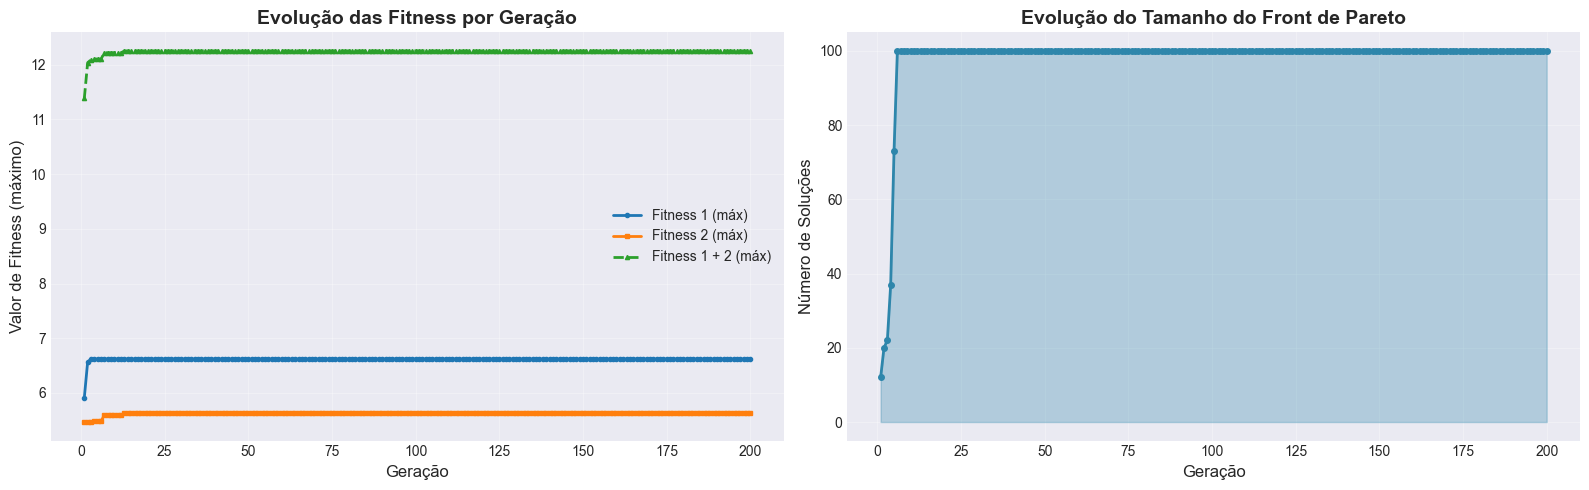


✅ Gráficos de progresso gerados com sucesso!

✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 100


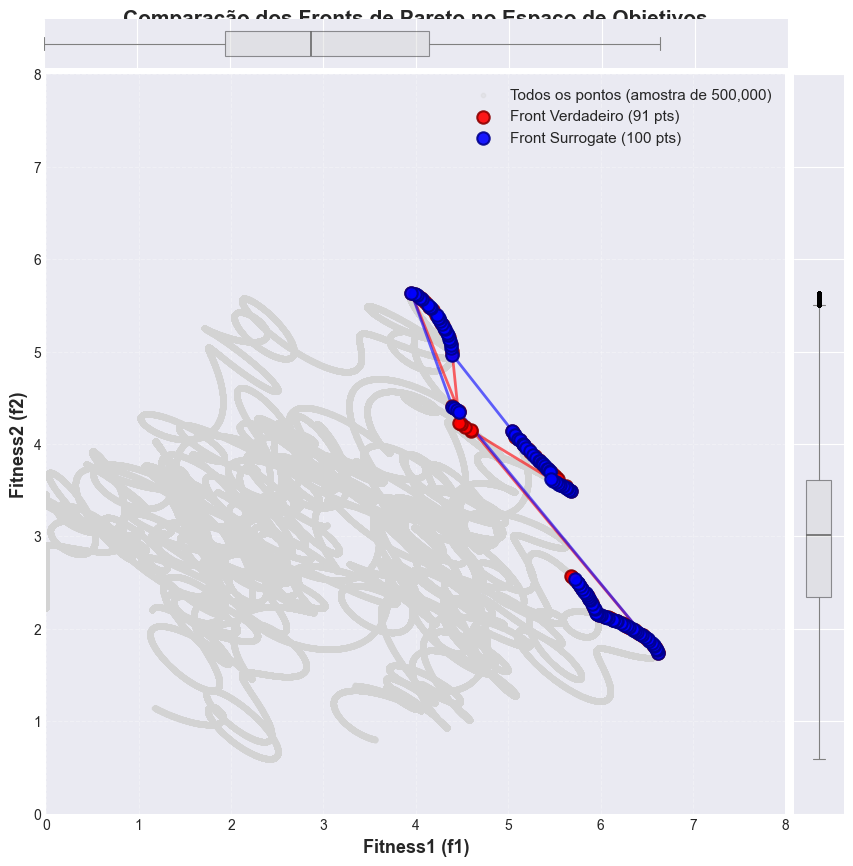

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 91
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.012509
   • Desvio Padrão:            0.011824

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.061799
   • Mediana:                  0.009180

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


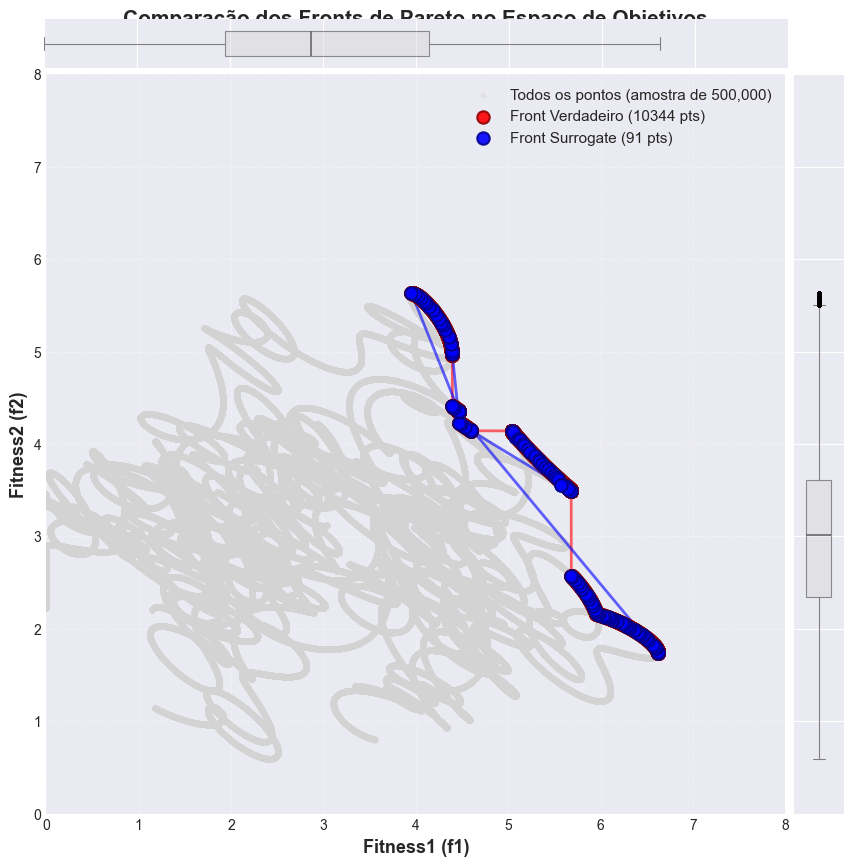

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 10,344
   • Pontos no front encontrado: 91

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.000948
   • Desvio Padrão:            0.004852

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.031406
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


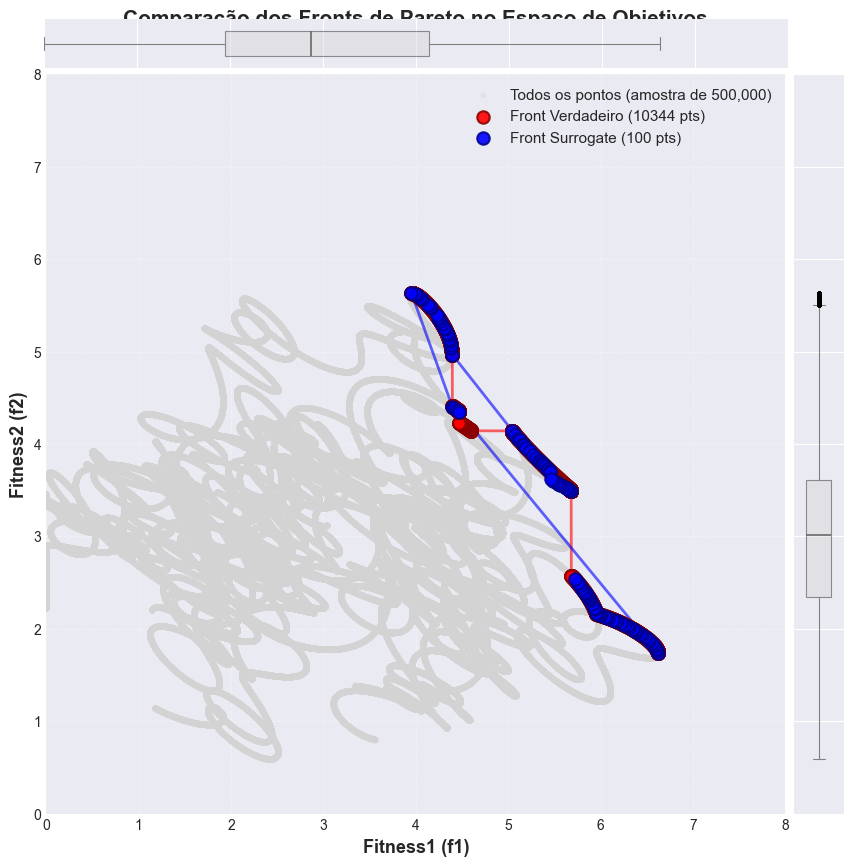

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 10,344
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.003356
   • Desvio Padrão:            0.010887

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.060467
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [11]:
# experimento
df_pareto_real = find_pareto_front(df)
df_pareto_my, _, _  = run_my_nsga2(config, df.copy())
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df.copy())

# convergencia entre resultados
display_two_pareto_fronts(df, df_pareto_my, df_pareto_moo)
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_two_pareto_fronts(df, df_pareto_real, df_pareto_my)
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_two_pareto_fronts(df, df_pareto_real, df_pareto_moo)
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_moo)
print_gamma_metric(gamma_results)

### 3.2. Landscape Previsto (maximizar)

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 318 pontos.
Isso representa 0.0318% do espaço de busca.


100%|██████████| 200/200 [00:12<00:00, 15.56it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 48


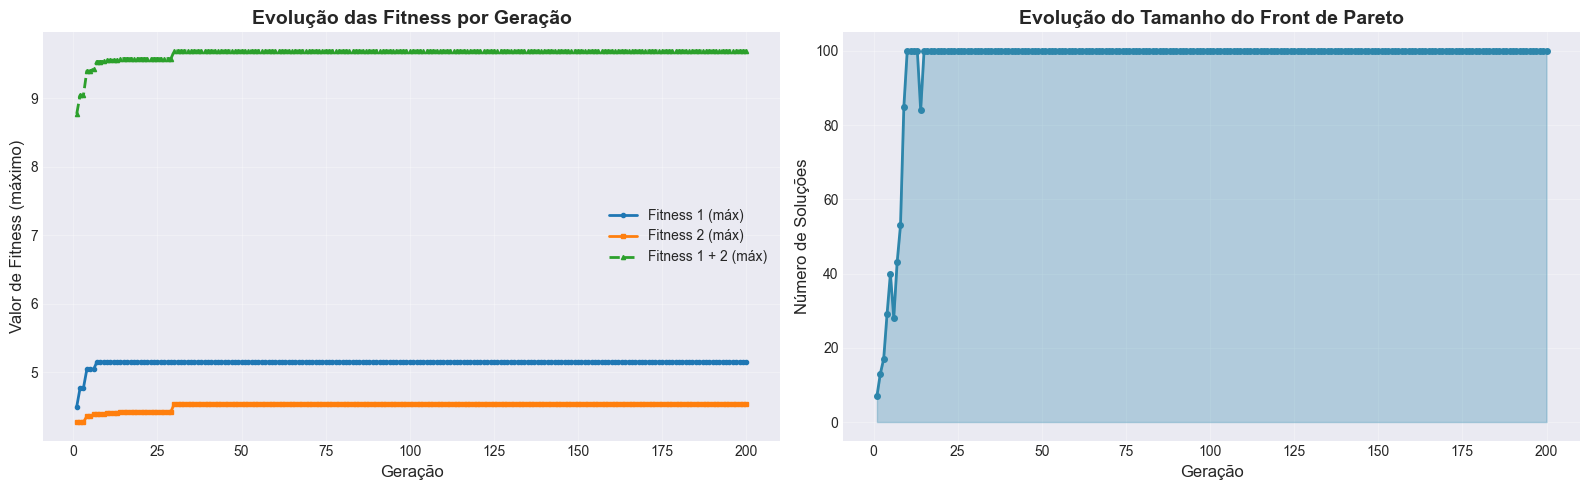


✅ Gráficos de progresso gerados com sucesso!

✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 100


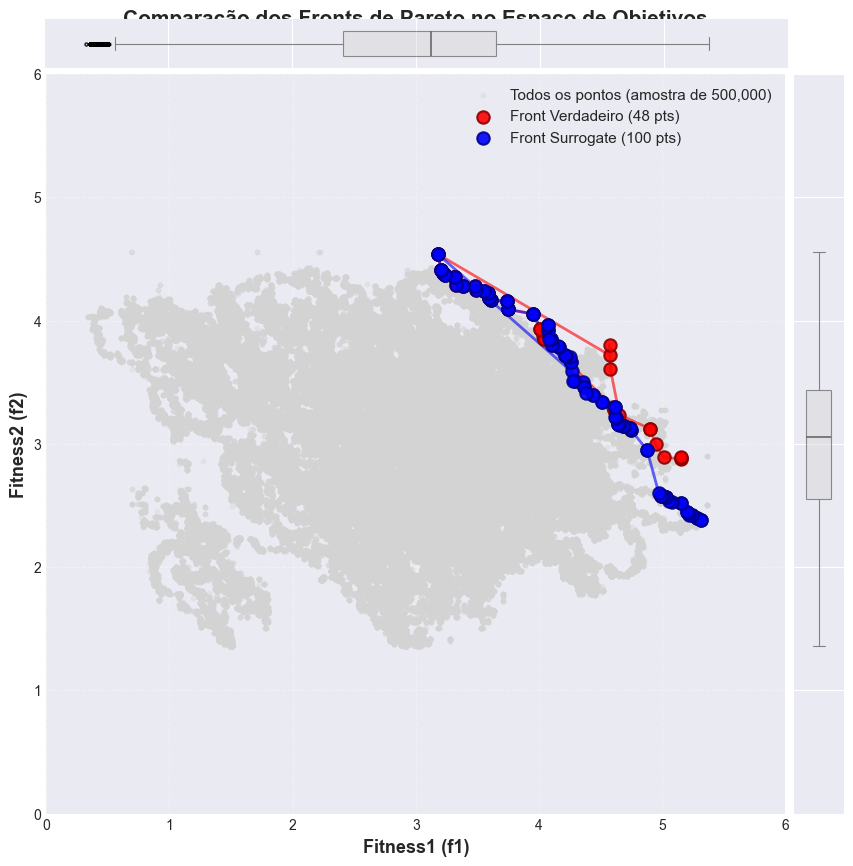

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 48
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.145419
   • Desvio Padrão:            0.162888

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.517863
   • Mediana:                  0.052505

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


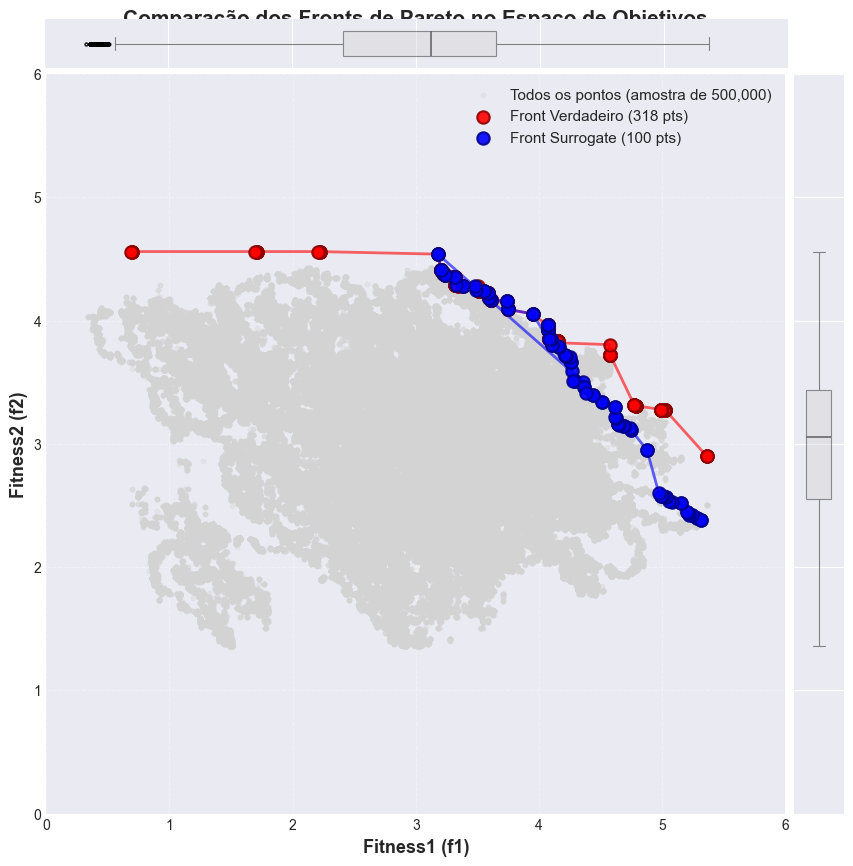

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 318
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.189225
   • Desvio Padrão:            0.188316

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.518124
   • Mediana:                  0.176160

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


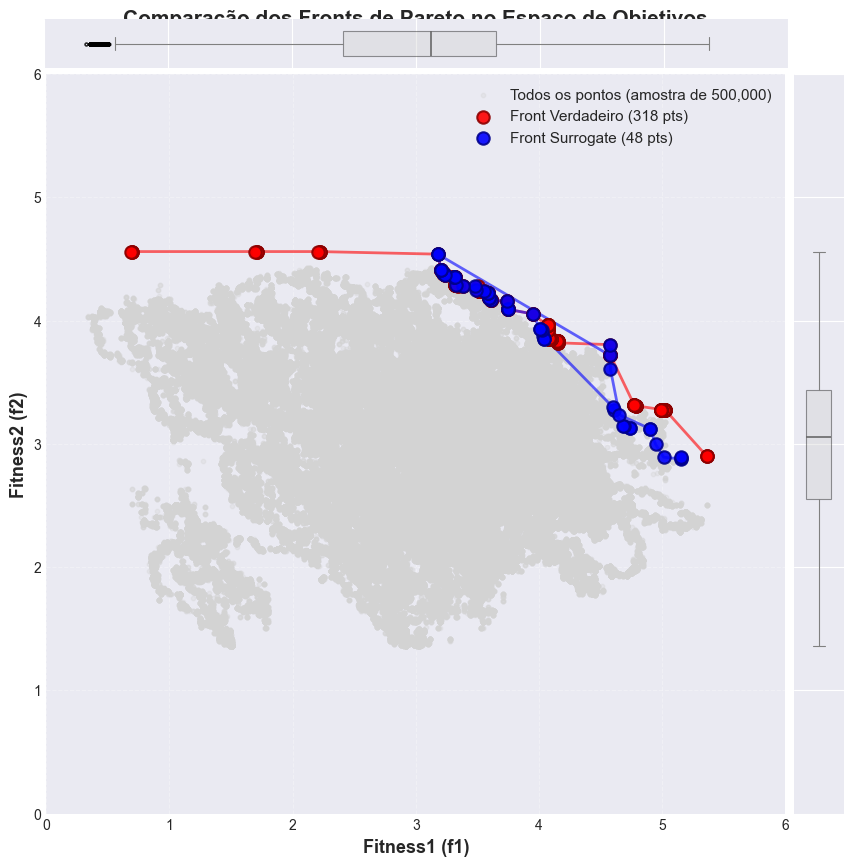

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 318
   • Pontos no front encontrado: 48

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.069236
   • Desvio Padrão:            0.093563

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.349252
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [ ]:
# experimento
df_predicted = df.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)

df_pareto_surrogate = find_pareto_front(df_predicted)
df_pareto_my, _, _  = run_my_nsga2(config, df_predicted.copy())
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df_predicted.copy())

# convergencia entre resultados
display_two_pareto_fronts(df_predicted, df_pareto_my, df_pareto_moo)
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_two_pareto_fronts(df_predicted, df_pareto_surrogate, df_pareto_my)
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_two_pareto_fronts(df_predicted, df_pareto_surrogate, df_pareto_moo)
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_moo)
print_gamma_metric(gamma_results)


# Outros

### Comparando funções de crossover e mutação com Pymoo 
* (não são similares)